# Algorithmes d'Apprentissages - Exercice 3 TD2
Alexandre DUFORET TD I

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("/content/auto.csv", delimiter = ",")

## Étape 1

### Question 1

In [5]:
df.head(10)

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
5,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
6,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
7,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
8,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?
9,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16430


Il n'y a pas vraiment d'entête car la première ligne contient elle-même des données. Il manque donc des titres aux colonnes. On trouve également le symbole "$?$" qui n'a pas vraiment de sens et il va donc falloir nettoyer le Data Frame.

### Question 2

In [6]:
col_names = [ "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
              "num-of-doors", "body-style", "drive-wheels", "emplacement du moteur",
              "empattement", "longueur", "largeur", "hauteur", "poids à vide", "type de moteur",
              "nombre de cylindres", "taille du moteur", "système de carburant", "alésage",
              "course", "taux de compression", "puissance", "crème-rpm", "ville-mpg",
              "autoroutempg", "prix" ]

df = pd.read_csv('auto.csv', header=None, names=col_names)

df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,emplacement du moteur,empattement,...,taille du moteur,système de carburant,alésage,course,taux de compression,puissance,crème-rpm,ville-mpg,autoroutempg,prix
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


### Question 3

In [7]:
display(df.head())
display(df.tail())
df.info()
print("\n")
print(f"On trouve {df.shape} observations dans le Data Frame.")
print("\n")
df.dtypes
print("\n")
display(df.describe())
display(df.describe(include='object'))

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,emplacement du moteur,empattement,...,taille du moteur,système de carburant,alésage,course,taux de compression,puissance,crème-rpm,ville-mpg,autoroutempg,prix
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,emplacement du moteur,empattement,...,taille du moteur,système de carburant,alésage,course,taux de compression,puissance,crème-rpm,ville-mpg,autoroutempg,prix
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470
204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symboling              205 non-null    int64  
 1   normalized-losses      205 non-null    object 
 2   make                   205 non-null    object 
 3   fuel-type              205 non-null    object 
 4   aspiration             205 non-null    object 
 5   num-of-doors           205 non-null    object 
 6   body-style             205 non-null    object 
 7   drive-wheels           205 non-null    object 
 8   emplacement du moteur  205 non-null    object 
 9   empattement            205 non-null    float64
 10  longueur               205 non-null    float64
 11  largeur                205 non-null    float64
 12  hauteur                205 non-null    float64
 13  poids à vide           205 non-null    int64  
 14  type de moteur         205 non-null    object 
 15  nombre

,symboling,empattement,longueur,largeur,hauteur,poids à vide,taille du moteur,taux de compression,ville-mpg,autoroutempg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,emplacement du moteur,type de moteur,nombre de cylindres,système de carburant,alésage,course,puissance,crème-rpm,prix
count,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205
unique,52,22,2,2,3,5,3,2,7,7,8,39,37,60,24,187
top,?,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.62,3.40,68,5500,?
freq,41,32,185,168,114,96,120,202,148,159,94,23,20,19,37,4


## Étape 2

### Question 4

In [8]:
print(df.isna().sum())

symboling                0
normalized-losses        0
make                     0
fuel-type                0
aspiration               0
num-of-doors             0
body-style               0
drive-wheels             0
emplacement du moteur    0
empattement              0
longueur                 0
largeur                  0
hauteur                  0
poids à vide             0
type de moteur           0
nombre de cylindres      0
taille du moteur         0
système de carburant     0
alésage                  0
course                   0
taux de compression      0
puissance                0
crème-rpm                0
ville-mpg                0
autoroutempg             0
prix                     0
dtype: int64


Il n'y a aucune valeur manquante détectée par la fonction .isna() car elles sont remplacées par "$?$" ce qui empêche leur détection.

### Question 5

In [9]:
df.replace("?", np.nan, inplace = True)

### Question 6

In [10]:
Doubles = df.duplicated().sum()
print(f"Nombre de doublon : {Doubles}.")
if Doubles > 0:
    df.drop_duplicates(inplace = True)

Nombre de doublon : 0.


### Question 7

In [11]:
print(df.isna().sum())
print(f"Nombre total de données manquantes : {df.isna().sum().sum()}")
print(f"Pourcentage de données manquantes : {round((df.isna().sum().sum() / df.size) * 100, 1)}%")

symboling                 0
normalized-losses        41
make                      0
fuel-type                 0
aspiration                0
num-of-doors              2
body-style                0
drive-wheels              0
emplacement du moteur     0
empattement               0
longueur                  0
largeur                   0
hauteur                   0
poids à vide              0
type de moteur            0
nombre de cylindres       0
taille du moteur          0
système de carburant      0
alésage                   4
course                    4
taux de compression       0
puissance                 2
crème-rpm                 2
ville-mpg                 0
autoroutempg              0
prix                      4
dtype: int64
Nombre total de données manquantes : 59
Pourcentage de données manquantes : 1.1%


### Question 8

In [12]:
NaValues = df.isna().sum()[df.isna().sum() > 0]
display(pd.DataFrame(NaValues, columns = ["Nombre Valeur NA"]))

,Nombre Valeur NA
normalized-losses,41
num-of-doors,2
alésage,4
course,4
puissance,2
crème-rpm,2
prix,4


### Question 9

In [13]:
print(df.dtypes.unique())

[dtype('int64') dtype('O') dtype('float64')]


### Question 10

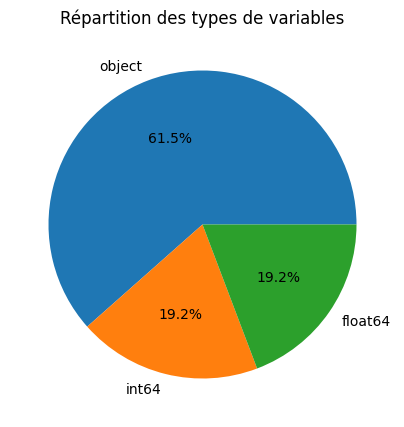

In [14]:
Counter = df.dtypes.value_counts()
Counter.plot(kind = "pie", autopct = "%1.1f%%", figsize = (5, 5),
             title = "Répartition des types de variables")

plt.ylabel('')
plt.show()

### Question 11 (a, b et c)

In [15]:
LimitNA = int(len(df) * 0.85)
df.dropna(axis = 1, thresh = LimitNA, inplace = True)

if "normalized-losses" not in df.columns:
    print("Colonne 'normalized-losses' supprimée !")
else:
    print("Hum... quelque chose n'a pas marché.")

ToCorrect = ["alésage", "course", "puissance", "crème-rpm"]

for col in ToCorrect:
    df[col] = df[col].astype("float64")
    TheMean = df[col].mean()
    df[col] = df[col].fillna(TheMean)

print("Colonnes converties en 'float64' et NA remplacés par la moyenne.")

df["num-of-doors"] = df["num-of-doors"].fillna("four")
print("Valeurs manquantes de 'num-of-doors' remplacées par 'four'.")

Colonne 'normalized-losses' supprimée !
Colonnes converties en 'float64' et NA remplacés par la moyenne.
Valeurs manquantes de 'num-of-doors' remplacées par 'four'.


### Question 12

In [16]:
df.dropna(axis = 0, inplace = True)

### Question 13

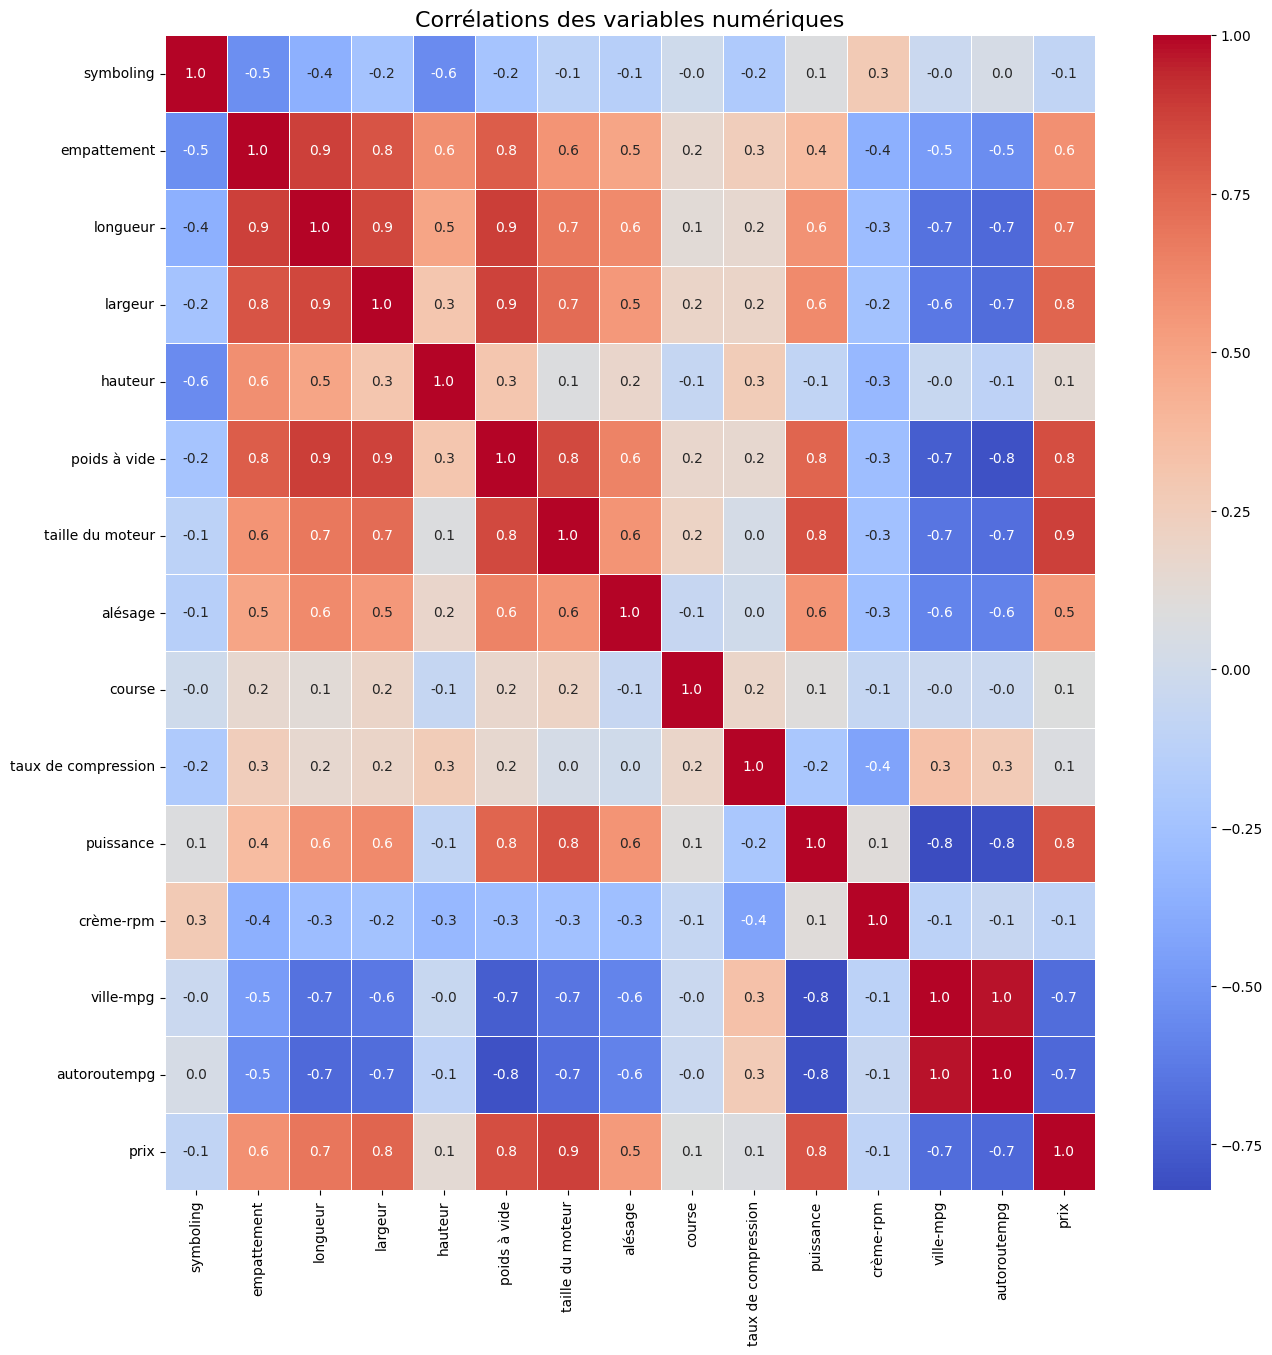

In [17]:
df['prix'] = df['prix'].astype('float64') # J'ai remarqué que la colonne "Prix" n'est pas de type int donc je la convertis
dfNum = df.select_dtypes(include=["float64", "int64"])
CorrMatrix = dfNum.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(CorrMatrix, annot = True, cmap = "coolwarm", fmt = ".1f", linewidths = 0.5)
plt.title('Corrélations des variables numériques', fontsize=16)
plt.show()

Les variables très fortement corrélées positivement entre elles sont :

* `ville-mpg` et `autoroutempg` (1.0) : une voiture qui consomme peu en ville consommera peu sur l'autoroute.

* `longueur`, `largeur` et `empattement` (0.8 à 0.9) : les dimensions d'une voiture sont très liées entre elles.

* `poids à vide`, `longueur et largeur` (0.9) : plus une voiture est grande et large, plus elle est lourde.

* `taille du moteur`, `puissance` et `poids à vide` (0.8) : les voitures les plus lourdes ont besoin de plus gros moteurs et développent plus de puissance.

Les variables fortement corrélées négativement entre elles sont :

* `poids à vide` vs `ville-mpg` / `autoroutempg` (-0.7 et -0.8) : plus la voiture est lourde, moins elle fait de *mile* par *gallon* (donc elle consomme plus).

* `puissance` vs `ville-mpg` / `autoroutempg` (-0.8) : plus la voiture est puissante, moins elle est économe en carburant.

### Question 14

In [18]:
XColumns = ["longueur", "largeur", "hauteur", "prix"]
X = df[XColumns]

Scaler = StandardScaler()
XScaled = Scaler.fit_transform(X)

XScaledDF = pd.DataFrame(XScaled, columns = XColumns)

### Question 15

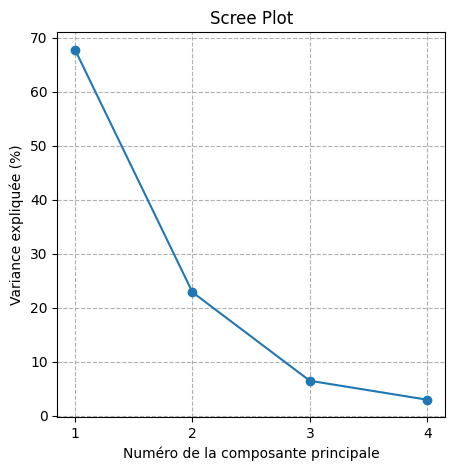

In [19]:
TestPCA = PCA()
TestPCA.fit(XScaledDF)

ExpVar = TestPCA.explained_variance_ratio_ * 100

plt.figure(figsize=(5, 5))
plt.plot(range(1, len(ExpVar) + 1), ExpVar, marker = "o")
plt.title("Scree Plot")
plt.xlabel("Numéro de la composante principale")
plt.ylabel("Variance expliquée (%)")
plt.xticks([1, 2, 3, 4])
plt.grid(True, linestyle = "--")
plt.show()

### Question 16

In [20]:
ThePCA = PCA(n_components=2)
XPCA = ThePCA.fit_transform(XScaledDF)

PCADF = pd.DataFrame(data = XPCA, columns = ["Composante Principale 1", "Composante Principale 2"])

print(f"CP 1 : {ThePCA.explained_variance_ratio_[0]*100:.1f}%")
print(f"CP 2 : {ThePCA.explained_variance_ratio_[1]*100:.1f}%")

CP 1 : 67.8%
CP 2 : 22.8%


### Question 17

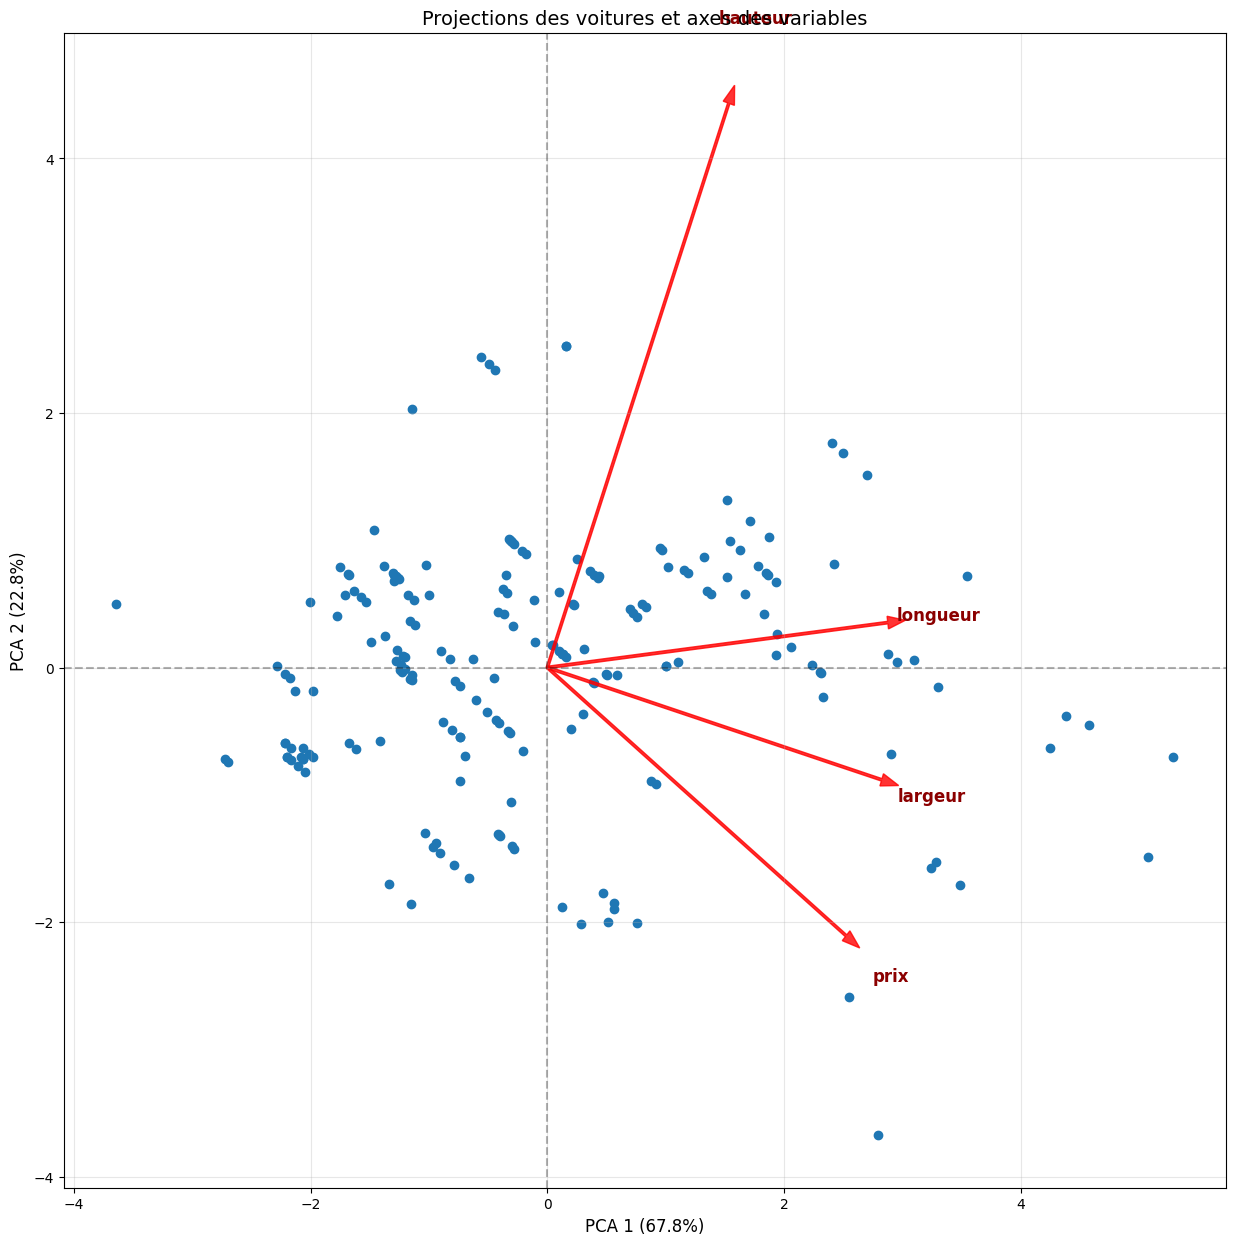

In [22]:
plt.figure(figsize=(15, 15))
plt.scatter(PCADF["Composante Principale 1"], PCADF["Composante Principale 2"])

coeff = ThePCA.components_.T
labels = XColumns
scale_arrow = 5

for i in range(len(labels)):
    plt.arrow(0, 0, coeff[i, 0] * scale_arrow, coeff[i, 1] * scale_arrow,
              color="red", alpha = 0.8, width = 0.02, head_width = 0.1)
    plt.text(coeff[i, 0] * scale_arrow * 1.15, coeff[i, 1] * scale_arrow * 1.15,
             labels[i], color = "darkred", fontsize = 12, fontweight = "bold", ha = "center", va = "center")

plt.xlabel(f"PCA 1 ({ThePCA.explained_variance_ratio_[0]*100:.1f}%)", fontsize = 12)
plt.ylabel(f"PCA 2 ({ThePCA.explained_variance_ratio_[1]*100:.1f}%)", fontsize = 12)
plt.title("Projections des voitures et axes des variables", fontsize=14)
plt.axhline(y = 0, color = "k", linestyle = "--", alpha = 0.3)
plt.axvline(x = 0, color="k", linestyle = "--", alpha = 0.3)
plt.grid(alpha = 0.3)
plt.show()

L'application de la PCA à deux composantes est pleinement justifiée puisqu'elles capturent ensemble 90,6 % de l'information initiale (67,8 % pour l'axe 1 et 22,8 % pour l'axe 2). L'axe de la composante 1 représente l'encombrement et la gamme du véhicule et est fortement corrélé positivement à la longueur, la largeur et au prix. L'axe de la composante 2 traduit en grande partie la hauteur de la voiture. Grâce à cette Analyse en Composantes Principales à deux dimensions nous pouvons cartographier efficacement le marché automobile : la majorité des véhicules forme un nuage central standard, autour duquel on trouve des cas aberrants, comme en bas à droite où l'on identifie des modèles très longs, larges et onéreux mais particulièrement bas donc des voitures sportives. Après consultation il s'agit effectivement d'une Mercedes-Benz équipée d'un moteur 8 cylindres !